In [22]:
import numpy as np
import os
import matplotlib.pyplot as plot
from plant.parameters import params

#### 1.1 Formulate optimization problem

$$
\begin{aligned}
    \min \quad  & J= \sum\limits_{k=0}^{N-1} \alpha\Delta t P_{fuel}(k) \quad &&& \text{objective function} \\[5pt]
\end{aligned}
$$

In [ ]:
#Define the parameters
Delta_t = 0.2

# Fuel consumption in grams per unit energy
alpha = 1e-4     # [g/(s-W)]
Voc = params['V_oc_nom'] 
Q_bat = params['E_pack_capacity'] /Voc

# Limits on Batt Power, Eng Power, SOC
P_batt_max = params['P_MGU_max']  # 350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

SOC_min = params['SoC_min']     # 0.1[-]
SOC_max = params['SoC_max']     # 0.9[-]

# Load Data
data = np.load('data/spanish_qualifying.npy')

t = data[0,:]
v = data[1,:]
a = data[2,:]


Text(0.5, 0, 'time (s)')

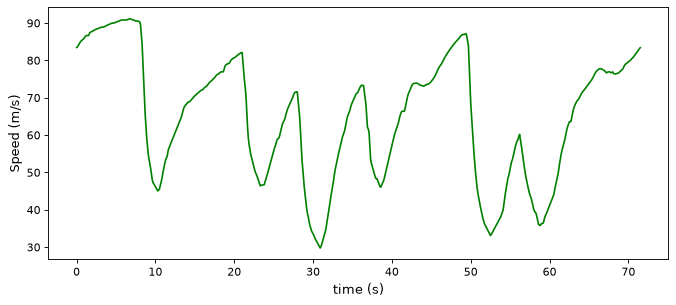

In [24]:
plot.figure(num=1, figsize=(10, 9), dpi=80, facecolor='w', edgecolor='k')

plot.subplot(2,1,1)
plot.plot(t,v,'g')
plot.ylabel('Speed (m/s)', fontsize= 12)
plot.xlabel('time (s)', fontsize= 12)

In [ ]:
SoC_grid = np.linspace(SOC_min,SOC_max, 72)

#Grid size
ns = len(SoC_grid) # No. of states

# Planning horizon (time steps)
N = len(t)

# Preallocate Value Function (rows index state, columns index time)
V = np.inf*np.ones((ns,N+1))


# Preallocate Control (rows index state, columns index time)
u_star = np.zeros((ns,N))

In [ ]:
# Boundary Condition of Value Function (Principle of Optimality)
V[:,N] = 0

# Iterate backward in time
for k in range(N-1,0,-1):

    # Iterate over SOC
    for idx in range(0,ns):
        # Find dominant bounds for P_batt
        lb = max([(((SOC_max - SoC_grid[idx]) * Q_bat * Voc) / -Delta_t), -P_batt_max, P_dem[k] - P_eng_max])
        up = 


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
